<a href="https://colab.research.google.com/github/nadiajelani/football_analytics/blob/main/deform_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install OpenCV if not already installed
!pip install opencv-python-headless


In [2]:
# Import libraries
import cv2
import numpy as np
import os
from google.colab import drive  # Import drive to mount Google Drive
# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
image_folder = '/content/drive/MyDrive/Colab Notebooks/Football/Drop 1'


In [4]:
# List to store image file names (assuming sequential names like frame1.bmp, frame2.bmp, etc.)
image_files = sorted([os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith('.bmp')])
if not image_files:
    raise ValueError(f"No .bmp files found in {image_folder}. Please check the folder path and ensure .bmp files exist.")

# Read the first image to initialize
frame = cv2.imread(image_files[0], cv2.IMREAD_GRAYSCALE)
if frame is None:
    raise ValueError(f"Failed to load the first image: {image_files[0]}")


In [5]:
# Preprocess the first frame
_, thresh = cv2.threshold(frame, 50, 255, cv2.THRESH_BINARY_INV)

# Find contours to get initial object position
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    largest_contour = max(contours, key=cv2.contourArea)
    M = cv2.moments(largest_contour)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = frame.shape[1] // 2, frame.shape[0] // 2  # Default center if no contour
else:
    cx, cy = frame.shape[1] // 2, frame.shape[0] // 2

# Initialize Kalman Filter (4 states: x, y, dx, dy; 2 measurements: x, y)
kalman = cv2.KalmanFilter(4, 2)
kalman.measurementMatrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0]], np.float32)
kalman.transitionMatrix = np.array([[1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0], [0, 0, 0, 1]], np.float32)
kalman.processNoiseCov = np.eye(4, dtype=np.float32) * 0.03
kalman.statePre = np.array([[cx], [cy], [0], [0]], np.float32)  # Initial state


In [6]:
# Apply Canny edge detection to find the surface line
edges = cv2.Canny(frame, 50, 150, apertureSize=3)

# Use Hough Transform to detect lines
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=100, maxLineGap=10)

# Find the horizontal line closest to the bottom (assuming it's the surface)
surface_y = frame.shape[0]  # Default to bottom if no line is found
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if abs(y1 - y2) < 10:  # Horizontal line (small y difference)
            surface_y = min(y1, y2)  # Take the lowest y as the surface
            break

print(f"Detected surface at y = {surface_y}")


Detected surface at y = 446


Detected surface at y = 446
Frame 1451: Diameter = 178 pixels


<ipython-input-7-87bcde7de444>:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_cx, predicted_cy = int(prediction[0]), int(prediction[1])


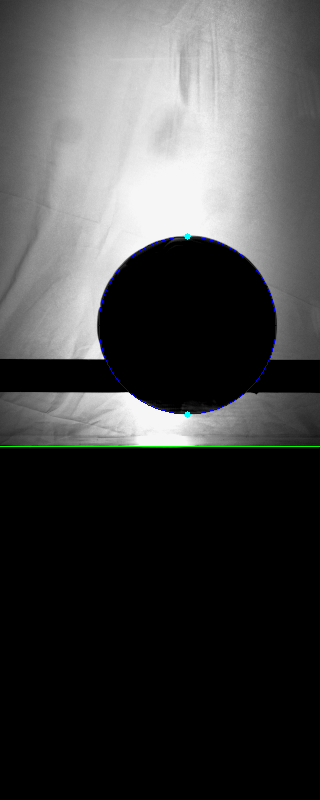

Frame 1452: Diameter = 176 pixels


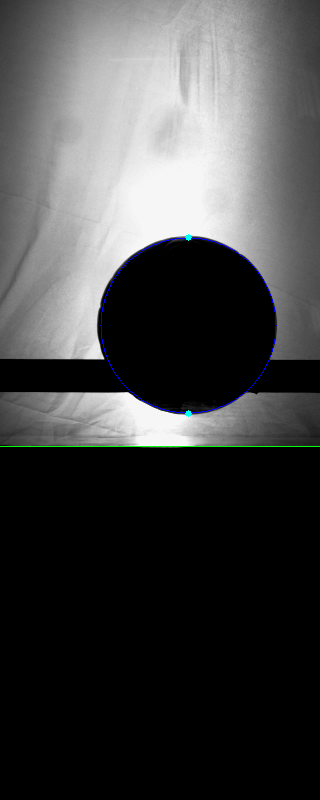

Frame 1453: Diameter = 176 pixels


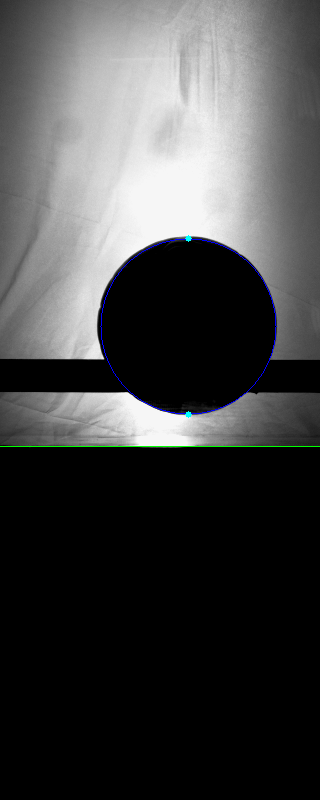

Frame 1454: Diameter = 176 pixels


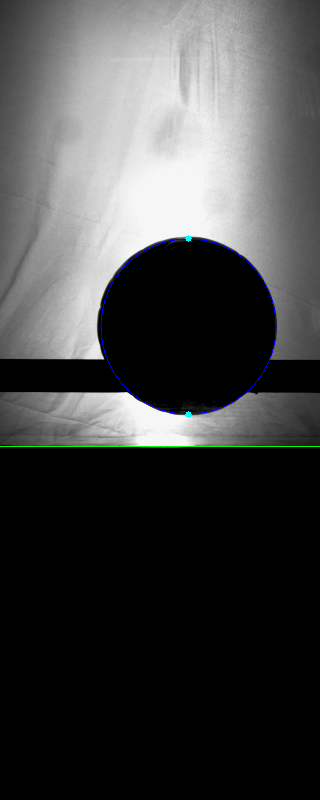

Frame 1455: Diameter = 176 pixels


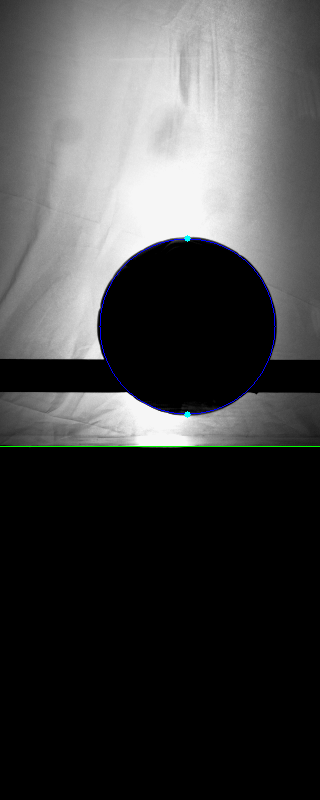

Frame 1456: Diameter = 176 pixels


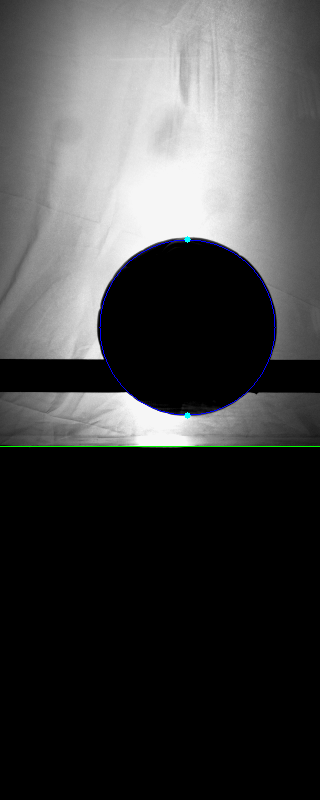

Frame 1457: Diameter = 176 pixels


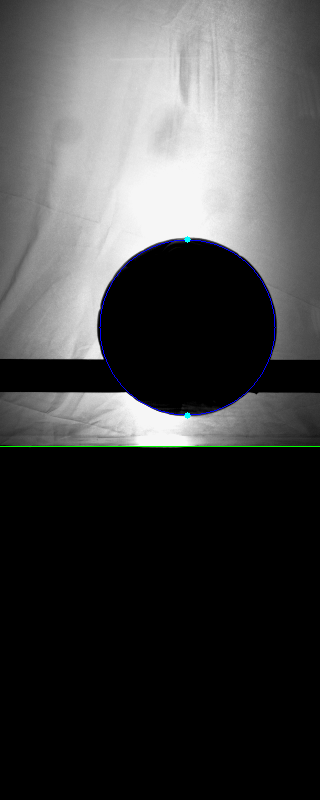

Frame 1458: Diameter = 176 pixels


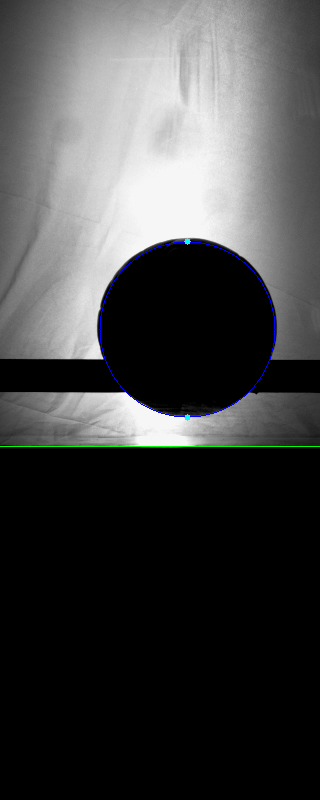

Frame 1459: Diameter = 176 pixels


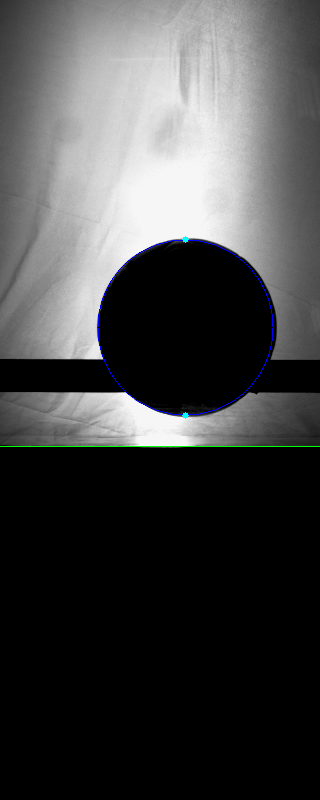

Frame 1460: Diameter = 176 pixels


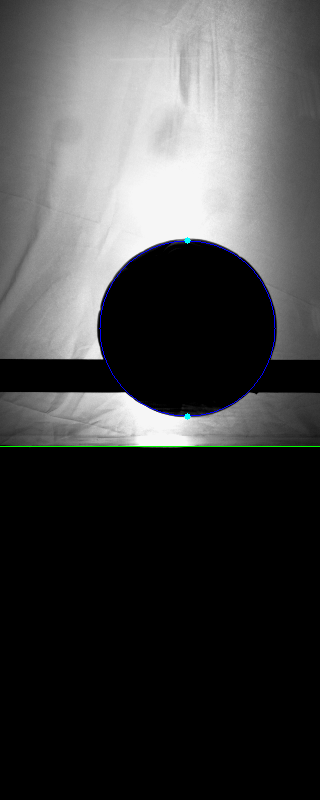

Frame 1461: Diameter = 176 pixels


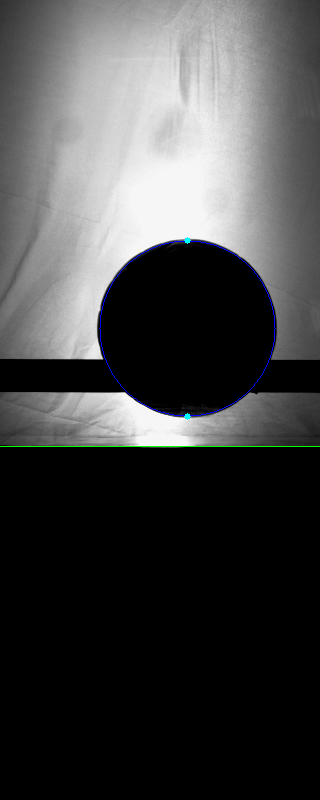

Frame 1462: Diameter = 176 pixels


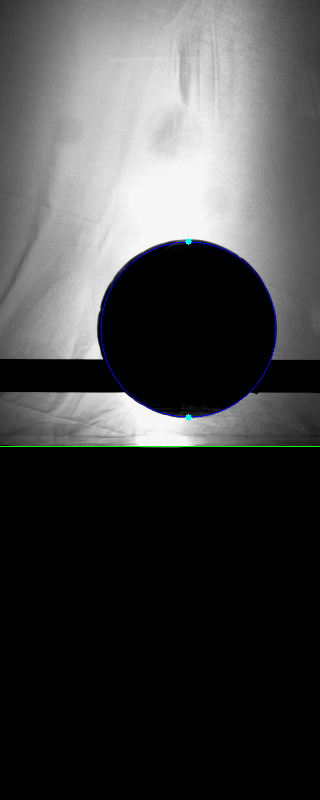

Frame 1463: Diameter = 176 pixels


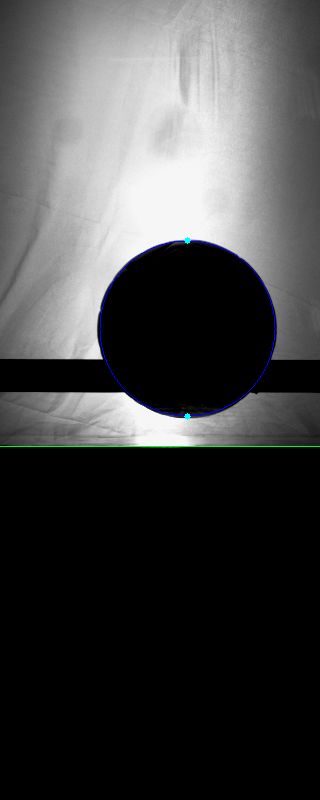

Frame 1464: Diameter = 176 pixels


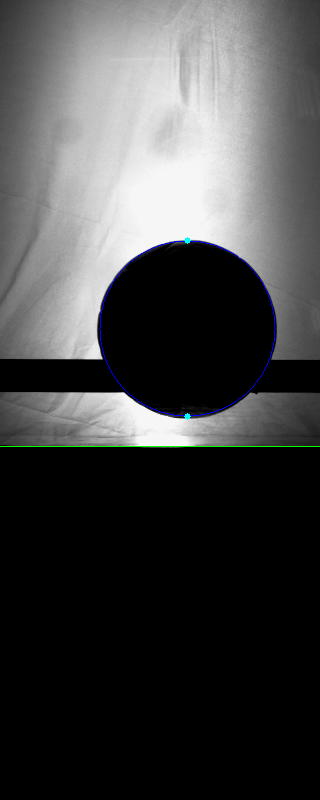

Frame 1465: Diameter = 176 pixels


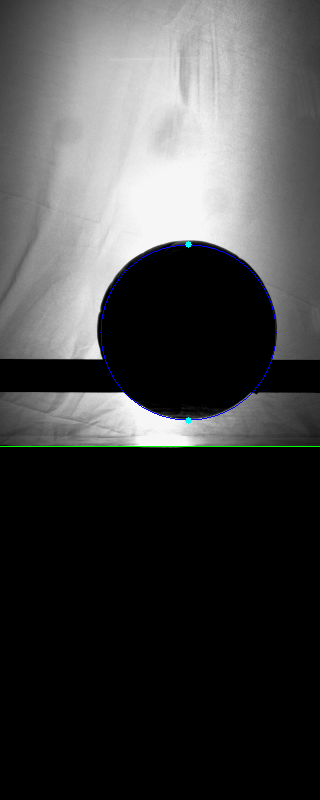

Frame 1466: Diameter = 176 pixels


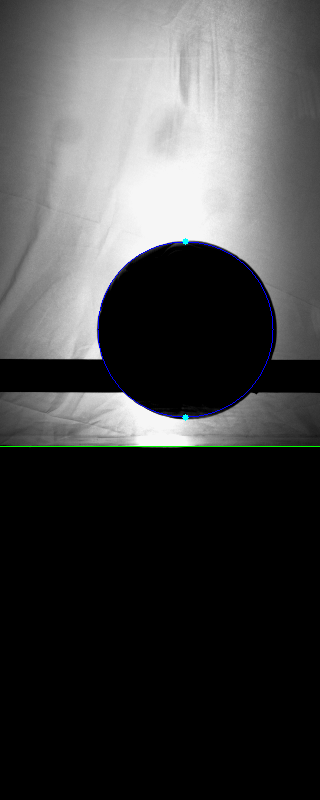

Frame 1467: Diameter = 176 pixels


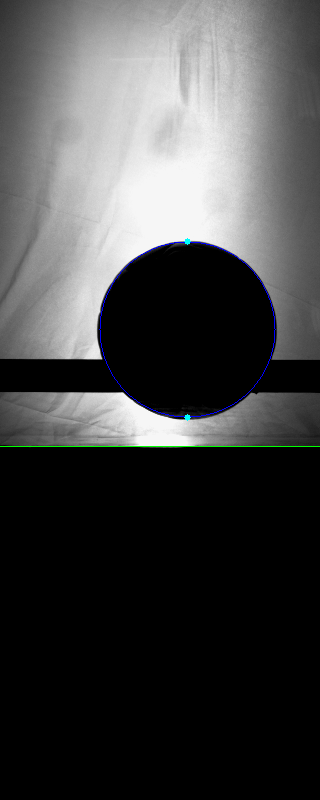

Frame 1468: Diameter = 176 pixels


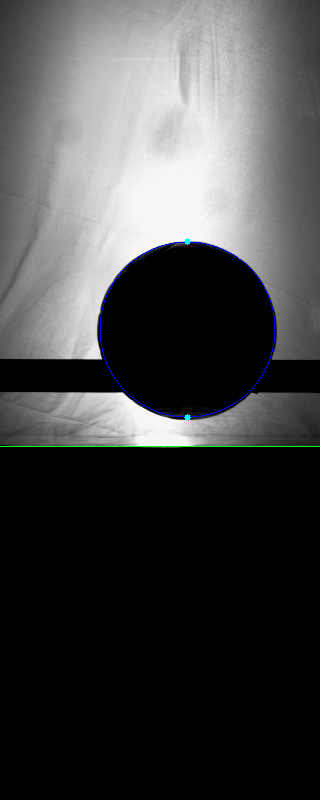

Frame 1469: Diameter = 176 pixels


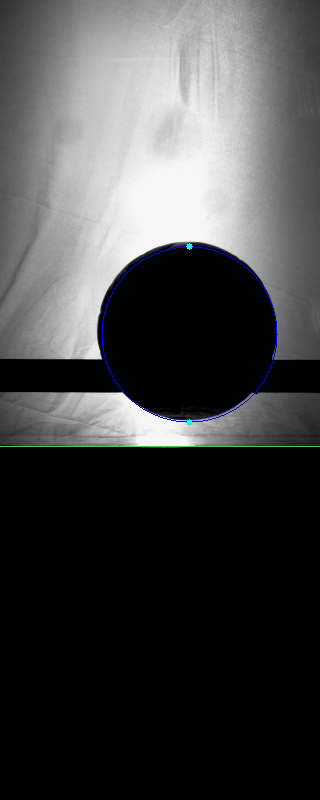

Frame 1470: Diameter = 176 pixels


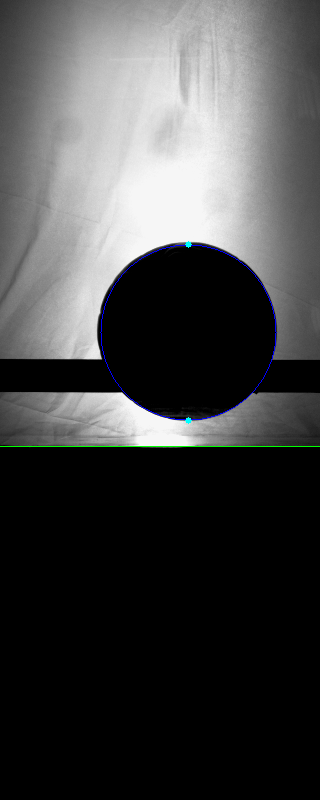

Frame 1471: Diameter = 176 pixels


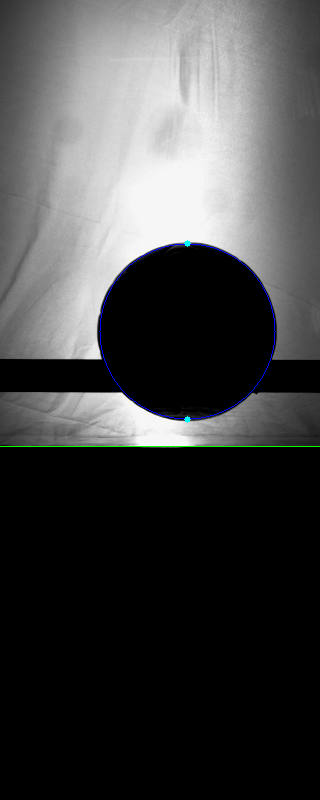

Frame 1472: Diameter = 176 pixels


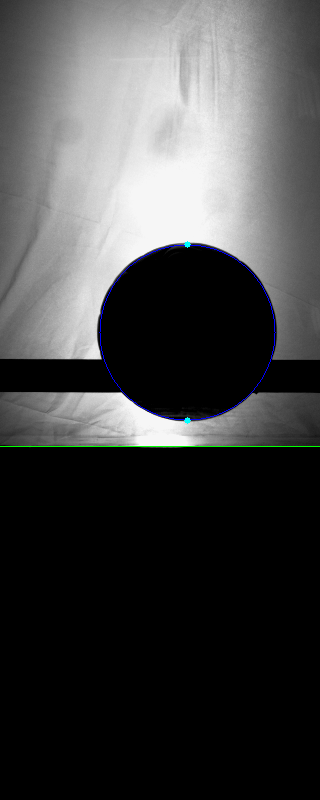

Frame 1473: Diameter = 176 pixels


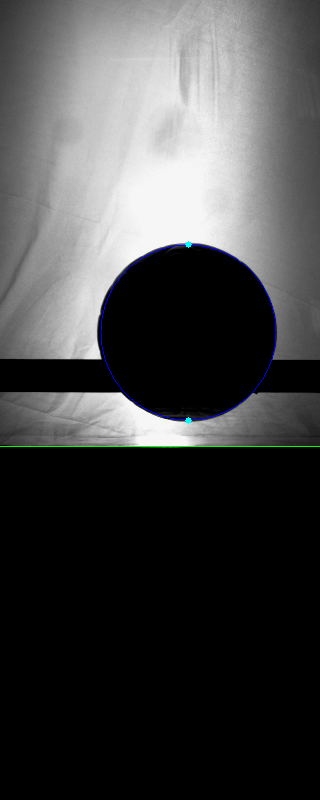

Frame 1474: Diameter = 176 pixels


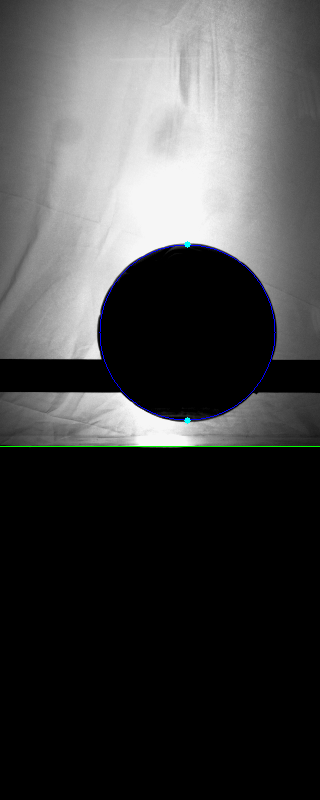

Frame 1475: Diameter = 176 pixels


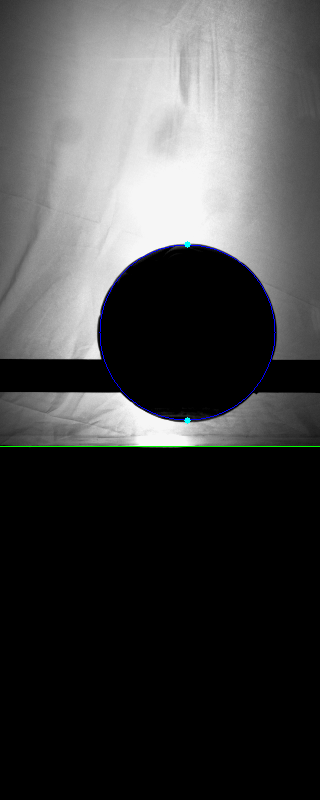

Frame 1476: Diameter = 176 pixels


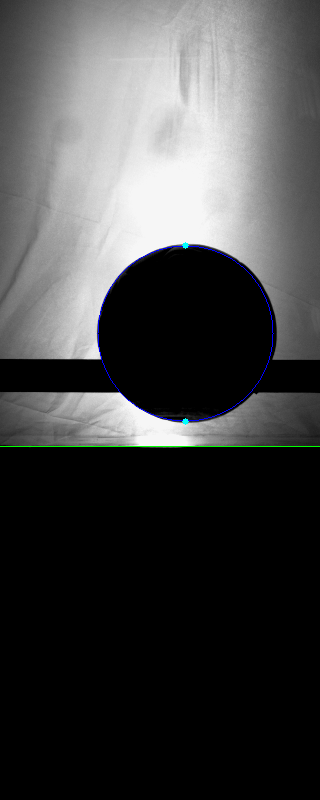

Frame 1477: Diameter = 176 pixels


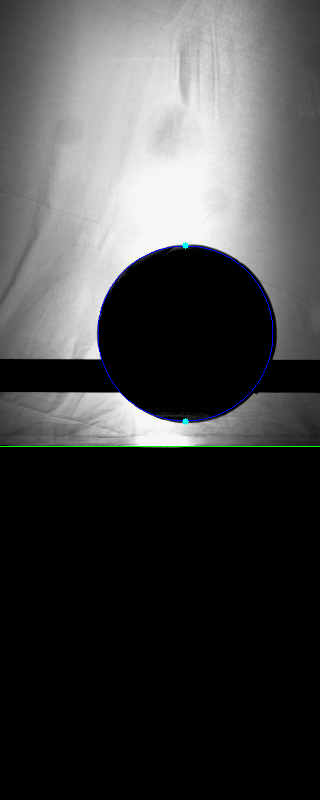

Frame 1478: Diameter = 176 pixels


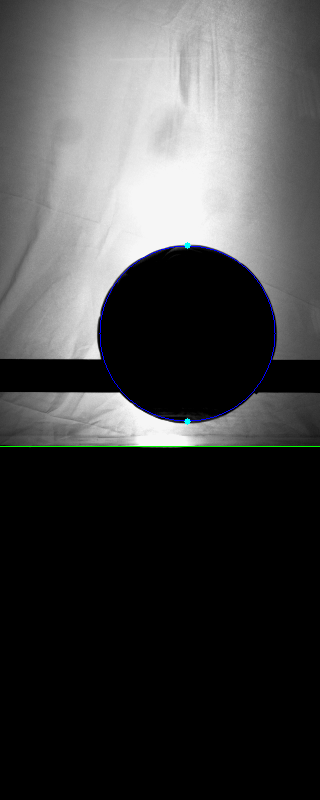

Frame 1479: Diameter = 176 pixels


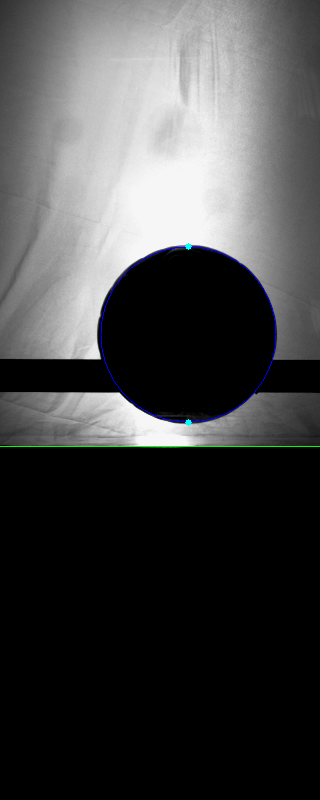

Frame 1480: Diameter = 176 pixels


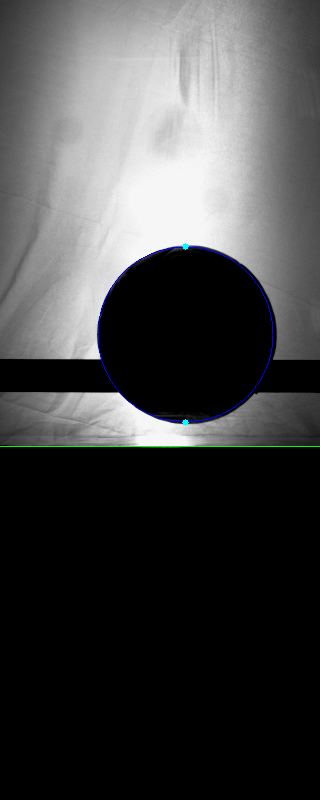

Frame 1481: Diameter = 176 pixels


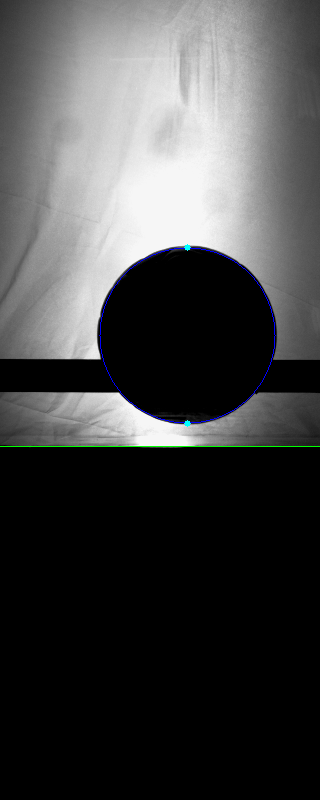

Frame 1482: Diameter = 176 pixels


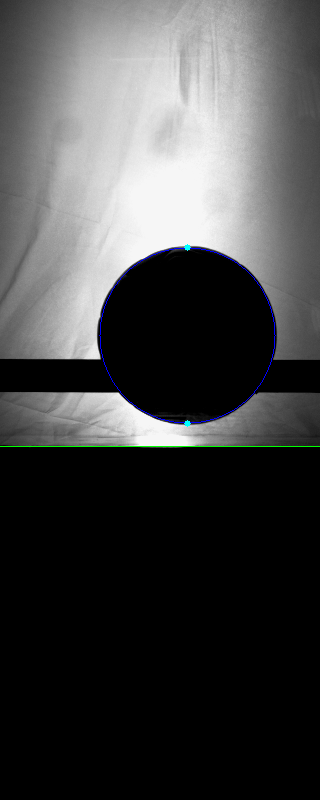

Frame 1483: Diameter = 176 pixels


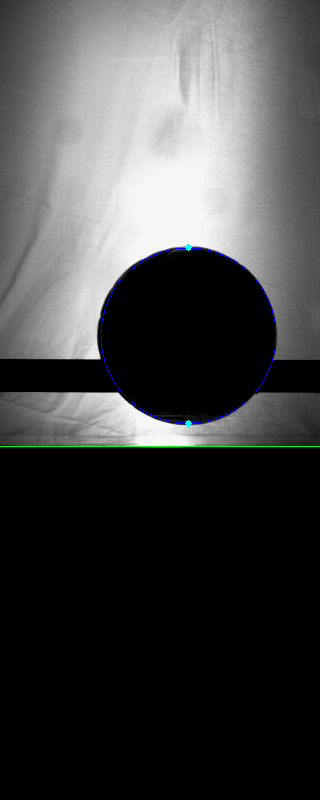

Frame 1484: Diameter = 176 pixels


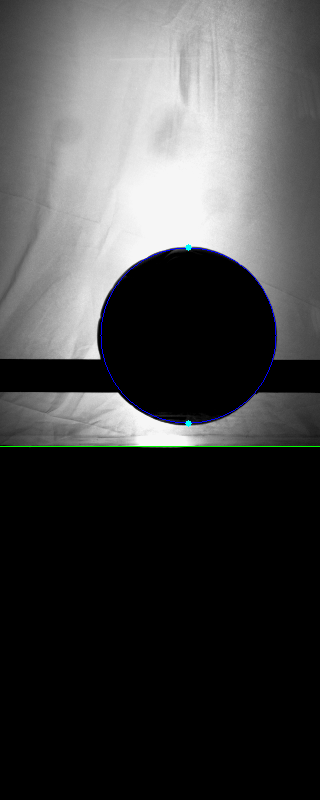

Frame 1485: Diameter = 176 pixels


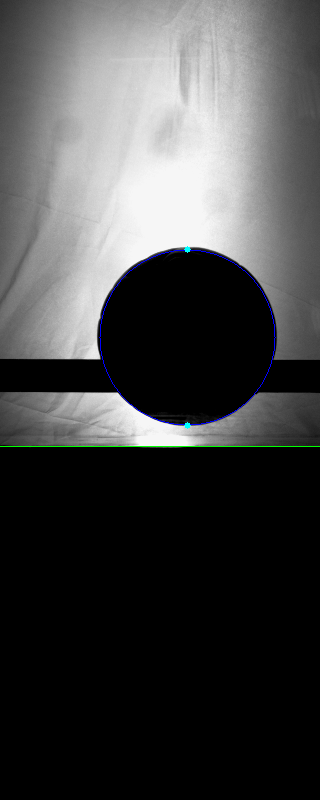

Frame 1486: Diameter = 176 pixels


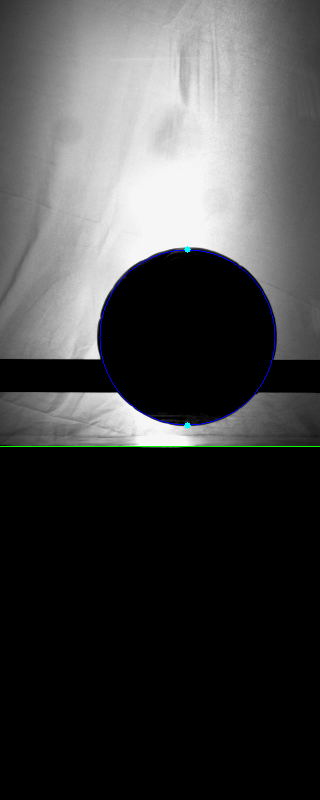

Frame 1487: Diameter = 176 pixels


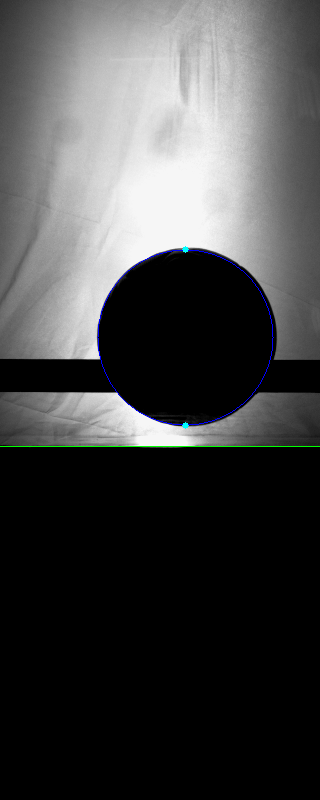

Frame 1488: Diameter = 176 pixels


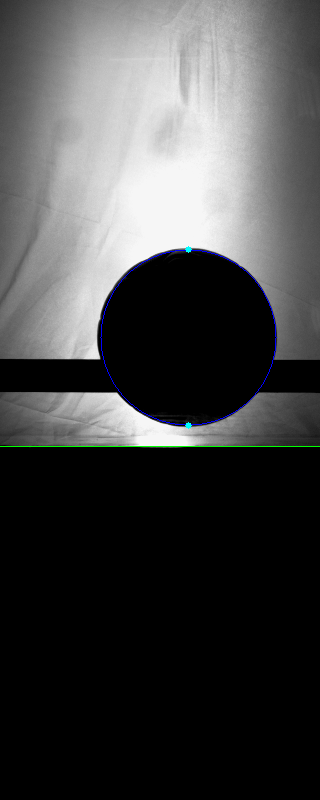

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

# Define image folder and load image files
image_folder = '/content/drive/MyDrive/Colab Notebooks/Football/Drop 1'
image_files = sorted([os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith('.bmp')])
if not image_files:
    raise ValueError(f"No .bmp files found in {image_folder}. Please check the folder path and ensure .bmp files exist.")

# Read the first image to initialize
frame = cv2.imread(image_files[0], cv2.IMREAD_GRAYSCALE)
if frame is None:
    raise ValueError(f"Failed to load the first image: {image_files[0]}")

# Detect surface line using Hough Transform
edges = cv2.Canny(frame, 50, 150, apertureSize=3)
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=100, maxLineGap=10)
surface_y = frame.shape[0]  # Default to bottom if no line is found
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if abs(y1 - y2) < 10:  # Horizontal line (small y difference)
            surface_y = min(y1, y2)  # Take the lowest detected horizontal line

print(f"Detected surface at y = {surface_y}")

# Kalman Filter Setup for Stable Circle Detection
kalman = cv2.KalmanFilter(4, 2)
kalman.measurementMatrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0]], np.float32)
kalman.transitionMatrix = np.array([[1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0], [0, 0, 0, 1]], np.float32)
kalman.processNoiseCov = np.eye(4, dtype=np.float32) * 0.02  # Increased smoothness
# Initialize Kalman Filter state with default values (will be updated with first detection)
kalman.statePre = np.array([[frame.shape[1] // 2], [frame.shape[0] // 2], [0], [0]], np.float32)

# Initialize Variables
D_original = None
last_valid_radius = None
last_valid_contact_points = None  # To track previous frame's contact points
data_records = []
dot_records = []  # To store dot positions

# Process frames 1450 to 1650
start_frame = 1450
end_frame = 1650
for i, img_file in enumerate(image_files):
    if i < start_frame or i >= end_frame:
        continue

    # Read and preprocess current frame
    frame = cv2.imread(img_file, cv2.IMREAD_GRAYSCALE)
    if frame is None:
        print(f"Failed to load {img_file}")
        continue

    # Apply Gaussian blur and thresholding
    blurred = cv2.GaussianBlur(frame, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

    # Detect circle using Hough Transform
    circles = cv2.HoughCircles(frame, cv2.HOUGH_GRADIENT, dp=1.2, minDist=50, param1=50, param2=30, minRadius=20, maxRadius=100)

    # Predict using Kalman Filter
    prediction = kalman.predict()
    predicted_cx, predicted_cy = int(prediction[0]), int(prediction[1])

    cx, cy, radius = None, None, None
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for circle in circles[0, :]:
            cx, cy, radius = circle  # Extract circle center and radius
            break  # Only take the first detected circle

        # Stabilize circle detection using Kalman Filter
        if last_valid_radius is not None:
            radius = int(0.85 * last_valid_radius + 0.15 * radius)  # Smooth transition
        last_valid_radius = radius  # Update last valid radius
        kalman.correct(np.array([[np.float32(cx)], [np.float32(cy)]]))
    else:
        # Use predicted values if no circle is detected
        cx, cy = predicted_cx, predicted_cy
        radius = last_valid_radius if last_valid_radius is not None else 50  # Fallback radius

    # Convert frame to color for drawing
    frame_color = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

    # Initialize dot positions as None
    top_dot_x, top_dot_y = None, None
    bottom_dot_x, bottom_dot_y = None, None
    contact_dot1_x, contact_dot1_y = None, None
    contact_dot2_x, contact_dot2_y = None, None
    diameter = 0
    contact_length = 0

    if radius is not None:
        # Define Top and Bottom Points
        top_point = (cx, cy - int(radius))
        bottom_point = (cx, cy + int(radius))

        # Ensure bottom point does not go below surface_y
        if bottom_point[1] >= surface_y:
            bottom_point = (cx, surface_y)

        # Store Top and Bottom Dot positions
        top_dot_x, top_dot_y = top_point
        bottom_dot_x, bottom_dot_y = bottom_point

        # Compute Diameter
        diameter = bottom_point[1] - top_point[1]
        diameter = max(diameter, 20)  # Avoid unrealistic values
        print(f"Frame {i + 1}: Diameter = {diameter} pixels")

        # Store initial diameter before deformation
        if D_original is None and bottom_point[1] < surface_y - 50:
            D_original = diameter
            print(f"Frame {i + 1}: D_original set to {D_original} pixels")

        # Draw Stable Blue Circle
        cv2.circle(frame_color, (cx, cy), int(radius), (255, 0, 0), 1)

        # Detect Contact Points (Yellow Dots)
        contact_point1 = None
        contact_point2 = None
        if bottom_point[1] == surface_y:  # When ball is in contact
            delta_y = surface_y - cy
            discriminant = radius**2 - delta_y**2
            if discriminant >= 0:
                sqrt_disc = np.sqrt(discriminant)
                x1 = int(cx - sqrt_disc)
                x2 = int(cx + sqrt_disc)
                contact_point1 = (x1, surface_y)
                contact_point2 = (x2, surface_y)
                contact_length = x2 - x1
                print(f"Contact detected! Contact Length: {contact_length} pixels")

                # Validate new contact points
                if last_valid_contact_points is not None:
                    x1_prev, x2_prev = last_valid_contact_points
                    if abs(x1 - x1_prev) > 10 or abs(x2 - x2_prev) > 10:
                        x1, x2 = x1_prev, x2_prev  # Use previous frame's values if new ones are unstable

                last_valid_contact_points = (x1, x2)  # Update valid points

                # Store Contact Dot positions
                contact_dot1_x, contact_dot1_y = contact_point1
                contact_dot2_x, contact_dot2_y = contact_point2

                # Draw Contact Dots in Yellow
                cv2.circle(frame_color, contact_point1, 3, (0, 255, 255), -1)
                cv2.circle(frame_color, contact_point2, 3, (0, 255, 255), -1)

    # Draw Surface Line (Green)
    cv2.line(frame_color, (0, surface_y), (frame.shape[1], surface_y), (0, 255, 0), 1)

    # Draw Top & Bottom Dots for Diameter (Cyan)
    if top_point is not None and bottom_point is not None:
        cv2.circle(frame_color, top_point, 3, (255, 255, 0), -1)
        cv2.circle(frame_color, bottom_point, 3, (255, 255, 0), -1)

    # Save Data for Original CSV (Diameter and Contact Length)
    data_records.append([i + 1, cx, cy, diameter, contact_length])

    # Save Dot Positions for New CSV
    dot_records.append([i + 1, top_dot_x, top_dot_y, bottom_dot_x, bottom_dot_y,
                        contact_dot1_x, contact_dot1_y, contact_dot2_x, contact_dot2_y])

    # Display Frame
    cv2_imshow(frame_color)
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cv2.destroyAllWindows()



### Calculations

In [ ]:
# Save Data to CSV
df = pd.DataFrame(data_records, columns=["Frame", "Ball_X", "Ball_Y", "Diameter", "Contact_Length"])
df.to_csv("/content/ball_deformation_data.csv", index=False)

# Create New CSV for Dot Positions
dot_df = pd.DataFrame(dot_records, columns=["Frame",
                                            "Top_Dot_X", "Top_Dot_Y",
                                            "Bottom_Dot_X", "Bottom_Dot_Y",
                                            "Contact_Dot1_X", "Contact_Dot1_Y",
                                            "Contact_Dot2_X", "Contact_Dot2_Y"])
dot_df.to_csv("/content/dot_positions.csv", index=False)

# Display the Dot Positions Table (First 10 Frames)
print("\nTable of Dot Positions (First 10 Frames):")
print(dot_df.head(10))

In [ ]:
Visual Rep

In [ ]:
# Generate Graphs for Dot Positions
# 1. X-Coordinates vs Frame
plt.figure(figsize=(12, 6))
plt.plot(dot_df["Frame"], dot_df["Top_Dot_X"], marker="o", linestyle="-", color="cyan", label="Top Dot X")
plt.plot(dot_df["Frame"], dot_df["Bottom_Dot_X"], marker="o", linestyle="-", color="blue", label="Bottom Dot X")
plt.plot(dot_df["Frame"], dot_df["Contact_Dot1_X"], marker="o", linestyle="-", color="yellow", label="Contact Dot 1 X")
plt.plot(dot_df["Frame"], dot_df["Contact_Dot2_X"], marker="o", linestyle="-", color="orange", label="Contact Dot 2 X")
plt.xlabel("Frame Number")
plt.ylabel("X-Coordinate (Pixels)")
plt.title("X-Coordinates of Dots Over Time")
plt.legend()
plt.grid(True)
plt.savefig("/content/x_coordinates_vs_frame.png")  # Save the plot
plt.show()

# 2. Y-Coordinates vs Frame
plt.figure(figsize=(12, 6))
plt.plot(dot_df["Frame"], dot_df["Top_Dot_Y"], marker="o", linestyle="-", color="cyan", label="Top Dot Y")
plt.plot(dot_df["Frame"], dot_df["Bottom_Dot_Y"], marker="o", linestyle="-", color="blue", label="Bottom Dot Y")
plt.plot(dot_df["Frame"], dot_df["Contact_Dot1_Y"], marker="o", linestyle="-", color="yellow", label="Contact Dot 1 Y")
plt.plot(dot_df["Frame"], dot_df["Contact_Dot2_Y"], marker="o", linestyle="-", color="orange", label="Contact Dot 2 Y")
plt.xlabel("Frame Number")
plt.ylabel("Y-Coordinate (Pixels)")
plt.title("Y-Coordinates of Dots Over Time")
plt.legend()
plt.grid(True)
plt.savefig("/content/y_coordinates_vs_frame.png")  # Save the plot
plt.show()

# 3. Trajectories (X vs Y) for Each Dot
plt.figure(figsize=(8, 8))
plt.plot(dot_df["Top_Dot_X"], dot_df["Top_Dot_Y"], marker="o", linestyle="-", color="cyan", label="Top Dot")
plt.plot(dot_df["Bottom_Dot_X"], dot_df["Bottom_Dot_Y"], marker="o", linestyle="-", color="blue", label="Bottom Dot")
plt.plot(dot_df["Contact_Dot1_X"], dot_df["Contact_Dot1_Y"], marker="o", linestyle="-", color="yellow", label="Contact Dot 1")
plt.plot(dot_df["Contact_Dot2_X"], dot_df["Contact_Dot2_Y"], marker="o", linestyle="-", color="orange", label="Contact Dot 2")
plt.xlabel("X-Coordinate (Pixels)")
plt.ylabel("Y-Coordinate (Pixels)")
plt.title("Trajectories of Dots (X vs Y)")
plt.legend()
plt.grid(True)
plt.savefig("/content/trajectories_x_vs_y.png")  # Save the plot
plt.show()

## GROK

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

# Define image folder and load image files
image_folder = '/content/drive/MyDrive/Colab Notebooks/Football/Drop 1'
image_files = sorted([os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith('.bmp')])
if not image_files:
    raise ValueError(f"No .bmp files found in {image_folder}. Please check the folder path and ensure .bmp files exist.")

# Read the first image to initialize
frame = cv2.imread(image_files[0], cv2.IMREAD_GRAYSCALE)
if frame is None:
    raise ValueError(f"Failed to load the first image: {image_files[0]}")

# Apply Canny edge detection to find the surface line
edges = cv2.Canny(frame, 50, 150, apertureSize=3)

# Use Hough Transform to detect lines
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=100, maxLineGap=10)

# Find the horizontal line closest to the bottom (assuming it's the surface)
surface_y = frame.shape[0]  # Default to bottom if no line is found
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if abs(y1 - y2) < 10:  # Horizontal line (small y difference)
            surface_y = min(y1, y2)  # Take the lowest y as the surface
            break

print(f"Detected surface at y = {surface_y}")

# Store initial diameter for deformation tracking
D_original = None

# Initialize CSV data storage
data_records = []

# Circle size scaling factor (adjust this value to change circle size)
circle_scale_factor = 1.0  # Default: 1.0 (original size)

# Dot configuration (adjust these values to change dot color and size)
dot_color = (255, 255, 0)  # Color for top and bottom dots: Cyan (B, G, R)
contact_dot_color = (0, 255, 255)  # Color for contact dots: Yellow (B, G, R)
dot_radius = 3  # Size for all dots: 5 pixels, e.g., 3 for smaller, 7 for larger

# Process frames 1450 to 1650
start_frame = 1450
end_frame = 1650
for i, img_file in enumerate(image_files):
    if i < start_frame or i >= end_frame:
        continue

    # Read and preprocess current frame
    frame = cv2.imread(img_file, cv2.IMREAD_GRAYSCALE)
    if frame is None:
        print(f"Failed to load {img_file}")
        continue

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(frame, (5, 5), 0)

    # Apply adaptive thresholding for better contrast
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cx, cy, radius = None, None, None
    diameter = 0

    # Use HoughCircles for better detection
    circles = cv2.HoughCircles(frame, cv2.HOUGH_GRADIENT, dp=1.2, minDist=50, param1=50, param2=30, minRadius=20, maxRadius=100)

    if circles is not None:
        circles = np.uint16(np.around(circles))
        for circle in circles[0, :]:
            cx, cy, radius = circle  # Extract circle center and radius
            break  # Only take the first detected circle

        # Ensure radius doesn't jump too much
        if 'last_valid_radius' in locals():
            radius = int(0.9 * last_valid_radius + 0.1 * radius)  # Smooth transition

        last_valid_radius = radius  # Update last valid radius

        # Calculate top and bottom points based on enclosing circle
        top_point = (cx, cy - int(radius))
        bottom_point = (cx, cy + int(radius))

        # Adjust bottom point during contact
        if bottom_point[1] >= surface_y - 5:
            bottom_point = (cx, surface_y)

        # Calculate diameter
        diameter = bottom_point[1] - top_point[1] if bottom_point[1] > top_point[1] else diameter
        diameter = max(diameter, 20)  # Minimum diameter to avoid collapse
        print(f"Frame {i + 1}: Diameter = {diameter} pixels")

        # Store initial diameter well before contact
        if D_original is None and bottom_point[1] < surface_y - 50:  # Ensure undeformed state
            D_original = diameter
            print(f"Frame {i + 1}: D_original set to {D_original} pixels")

    # Convert frame to color for drawing
    frame_color = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

    # Detect deformation
    deformation_threshold = 0.02  # 2% for sensitivity
    deformation_detected = D_original is not None and abs(diameter - D_original) > deformation_threshold * D_original

    # Draw the blue contour with scaled size
    if radius is not None:
        scaled_radius = int(radius * circle_scale_factor)  # Apply scaling factor
        cv2.circle(frame_color, (cx, cy), scaled_radius, (255, 0, 0), 1)  # Blue circle with scaled radius

    # Calculate intersection points of blue circle with green line
    contact_length = 0
    contact_point1 = None
    contact_point2 = None
    if radius is not None and bottom_point[1] == surface_y:  # When ball is in contact
        # Equation of circle: (x - cx)^2 + (y - cy)^2 = radius^2
        # Equation of line: y = surface_y
        delta_y = surface_y - cy
        print(f"Frame {i + 1}: cx={cx}, cy={cy}, scaled_radius={scaled_radius}, delta_y={delta_y}")
        if abs(delta_y) <= scaled_radius:  # Ensure intersection exists
            discriminant = scaled_radius**2 - delta_y**2
            if discriminant >= 0:
                sqrt_disc = np.sqrt(discriminant)
                x1 = int(cx - sqrt_disc)  # Left intersection point
                x2 = int(cx + sqrt_disc)  # Right intersection point
                contact_point1 = (x1, surface_y)
                contact_point2 = (x2, surface_y)
                contact_length = x2 - x1
                print(f"Contact detected! Contact Length: {contact_length} pixels")

                # Draw contact dots in yellow
                cv2.circle(frame_color, contact_point1, dot_radius, contact_dot_color, -1)  # Contact dot 1 (yellow)
                cv2.circle(frame_color, contact_point2, dot_radius, contact_dot_color, -1)  # Contact dot 2 (yellow)

    # Draw Surface Line (🟢 Green)
    cv2.line(frame_color, (0, surface_y), (frame.shape[1], surface_y), (0, 255, 0), 1)

    # Draw Top & Bottom Dots for Diameter (keep as cyan)
    cv2.circle(frame_color, top_point, dot_radius, dot_color, -1)  # Top dot (cyan)
    cv2.circle(frame_color, bottom_point, dot_radius, dot_color, -1)  # Bottom dot (cyan)

    # Display frame with diameter and contact length info
    text = f"Frame {i + 1}: Diameter = {diameter} pixels"
    if contact_length > 0:
        text += f"\nContact detected! Contact Length: {contact_length} pixels"
    cv2.putText(frame_color, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Display frame
    cv2_imshow(frame_color)
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cv2.destroyAllWindows()

# Save data to CSV
df = pd.DataFrame(data_records, columns=["Frame", "Ball_X", "Ball_Y", "Diameter", "Deformation_Length"])
df.to_csv("/content/ball_deformation_data.csv", index=False)

# Plot deformation over time
plt.figure(figsize=(10, 5))
plt.plot(df["Frame"], df["Deformation_Length"], marker="o", linestyle="-", color="r", label="Deformation Length")
plt.xlabel("Frame Number")
plt.ylabel("Deformation Length (pixels)")
plt.title("Deformation Over Time")
plt.legend()
plt.grid(True)
plt.show()